# Module 2: Epidemic Modeling Template

## Team Members:
* Dane Wleklinski
* Molly Janousek

## Project Title: Characterizing an Unkown Viral Illness


## Project Goal:
This project seeks to: estimate the initial growth rate from outbreak data, predict the spread of the disease, find when cases will peak, determine the virus family, and provide the best intervention strategy to reduce the spread of illness.

## 1. Data and disease background
### Prevalence & Incidence in the UVA population
![Incidence and Prevalence Graphs](incidence_prevalence.png)
__Highest Incidence:__
Day: 2026-05-04 00:00:00 (Day 65)
Incidence: 1.6927%
__Lowest Incidence:__
Day: 2026-05-06 00:00:00 (Day 67)
Incidence: -0.0503% (Note: Negative just means cases went down)
__Highest Prevalence:__
Day: 2026-05-08 00:00:00 (Day 69)
Prevalence: 13.2067%
__Lowest Prevalence:__
Day: 2026-03-01 00:00:00 (Day 1)
Prevalence: 0.0056%
### Economic Burden (you can generalize from respiratory viruses)

### Symptoms
* Mild respiratory symptoms
* Rash
* Low-grade Fever
* May have a sore throat, fatigue, and gastrointestinal issues
### Biological Mechanisms  you can generalize from viral biology
#### Anatomy
#### Physiology
##### Organ
##### Cell & Molecular


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### __Initial Analysis Questions:__
##### What do you notice about the initial infections?
The initial infections increase over time. The rate of increase accelerates, so the virus is spreading faster and faster. The curve is exponential.
##### How could we measure how quickly its spreading?
We could measure the rate of increase in the number of active cases over time. This can be done by calculating the growth rate, which is the percentage increase in active cases from one day to the next.
##### What information about the virus would be helpful in determining the shape of the outbreak curve?
Information about the virus's transmission rate, incubation period, and recovery time would be helpful in determining the shape of the outbreak curve.

### __Questions About Estimated R0:__

##### What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.

The estimated R0 for the mystery virus is 1.24, which is similar to the R0 of seasonal influenza (R0 of 1.3). 
Seasonal influenza is a contagious respiratory illness caused by influenza viruses, which can lead to mild to severe illness and can sometimes result in death,
particularly in vulnerable populations such as the elderly and those with underlying health conditions.

This R0 is also similar to the R0 of Rhinovirus (R0 of 1.5).
Rhinovirus is a common viral infectious agent that primarily causes the common cold. 
It is highly contagious and can lead to symptoms such as a runny nose, sore throat, cough, and congestion. Rhinovirus infections are typically mild and self-limiting,
but they can cause complications in individuals with weakened immune systems or pre-existing respiratory conditions.

##### How accurate do you think your R0 estimate is?
The R0 estimate is based on the early exponential growth phase of the outbreak, which can be influenced by various factors such as underreporting of cases, changes in testing rates, and public health interventions. Therefore, while the estimate provides a useful measure of transmissibility, it may not be perfectly accurate and should be interpreted with caution.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

This code loads the mystery virus data from the first data release and plots the daily active cases over time to visualize the initial spread. Then, we fit an exponential growth model to the data to estimate the R0 value, assuming an average infectious period of 2 days. We printed the R0, and display two plots to show the data points with the fitted exponential curve.

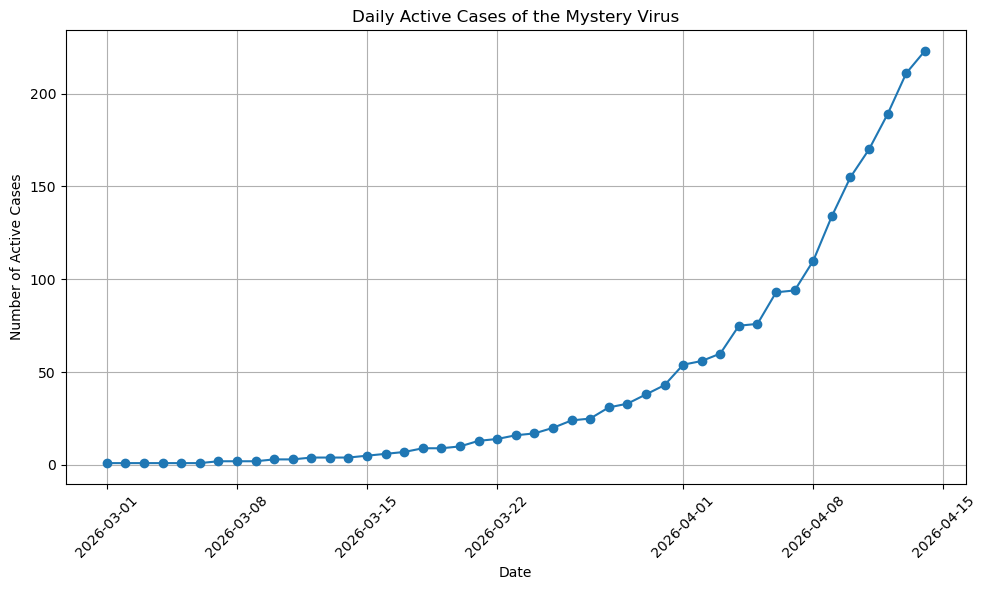

Estimated R0: 1.24


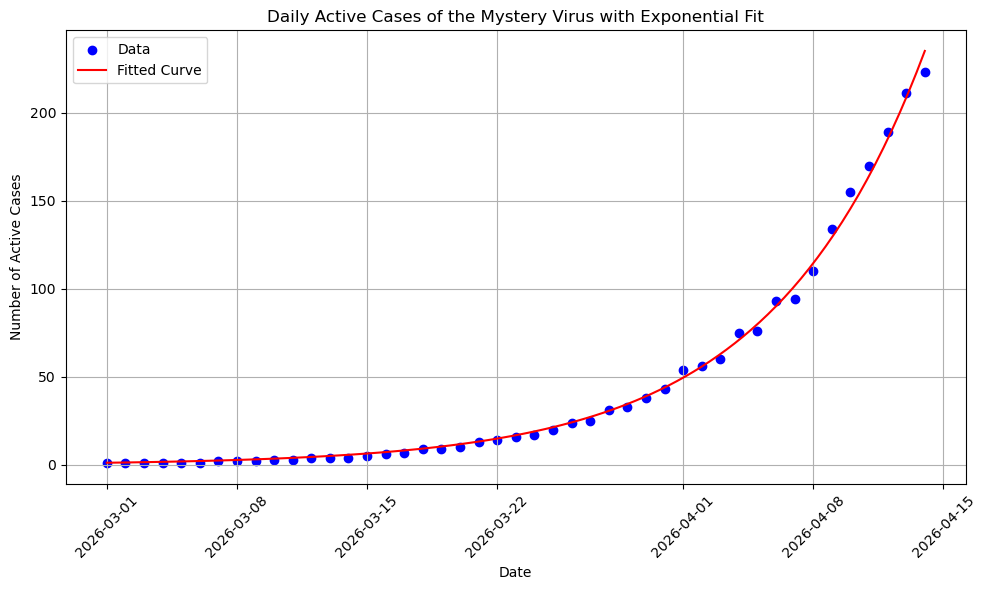

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

# Load the data
data = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

# Make a plot of the active cases over time
plt.figure(figsize=(10, 6))
plt.plot(data['date'], data['active reported daily cases'], marker='o', linestyle='-')
plt.title('Daily Active Cases of the Mystery Virus')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Define the exponential growth function
def exponential_growth(t, I0, r):
    return I0 * np.exp(r * t)

# Prepare the data for fitting
data['days'] = (data['date'] - data['date'].min()).dt.days

# Fit the exponential growth model to the data
popt, pcov = curve_fit(exponential_growth, data['days'], data['active reported daily cases'], p0=(1, 0.1))
I0, r = popt
R0 = 1 + r * 2  # average infectious period of 2 days
print(f"Estimated R0: {R0:.2f}")

# Plot the data and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(data['date'], data['active reported daily cases'], label='Data', color='blue')
t_fit = np.linspace(0, data['days'].max(), 100)
plt.plot(data['date'].min() + pd.to_timedelta(t_fit, unit='D'), exponential_growth(t_fit, *popt), label='Fitted Curve', color='red')
plt.title('Daily Active Cases of the Mystery Virus with Exponential Fit')
plt.xlabel('Date')
plt.ylabel('Number of Active Cases')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

*Summary of Analysis After Data Release #1:* The data revealed exponential growth in active cases over the initial period. Fitting an exponential model to the early data estimated R0 at 1.24, indicating moderate transmissibility comparable to seasonal influenza or rhinovirus. This R0 estimate provides a baseline for understanding the virus's ability to spread through populations.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>

### 2c. Use Euler's method to solve the SEIR model.

This code defines the SEIR (Susceptible-Exposed-Infected-Recovered) model differential equations and uses Euler's method for numerical integration. It loads the data from the second data release, sets initial conditions, and simulates the SEIR model using example parameter values (beta=0.3, sigma=0.2, gamma=0.1). The resulting plot shows Susceptible, Exposed, Infected, and Recovered populations over the observed period.

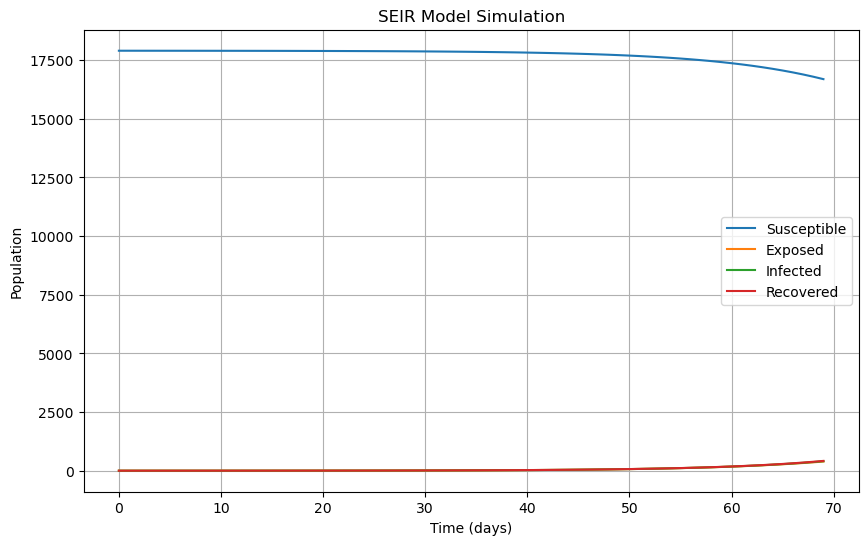

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data for RELEASE#2
data = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
observed_data = data["active reported daily cases"].values
num_days = len(observed_data)
timepoints = np.arange(num_days)

# SEIR differential equations
def seir_model(y, t, beta, sigma, gamma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# Euler method implementation
def euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    # Initial conditions
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    # Euler integration
    for i in range(1, len(timepoints)):
        dt = timepoints[i] - timepoints[i-1]
        dSdt, dEdt, dIdt, dRdt = seir_model(
            (S[i-1], E[i-1], I[i-1], R[i-1]),
            timepoints[i-1],
            beta, sigma, gamma, N
        )
        # Update values using Euler's method
        S[i] = S[i-1] + dSdt * dt
        E[i] = E[i-1] + dEdt * dt
        I[i] = I[i-1] + dIdt * dt
        R[i] = R[i-1] + dRdt * dt
    # return results
    return S, E, I, R

# Initial conditions
S0 = 17900
E0 = 0
I0 = 1
R0 = 1.24  # estimated from data
N = S0 + E0 + I0 + R0

# Example parameters (will be fitted later)
beta = 0.3
sigma = 0.2
gamma = 0.1

# Solve the SEIR model
S, E, I, R = euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N)

# Plot the SEIR model results
plt.figure(figsize=(10, 6))
plt.plot(timepoints, S, label='Susceptible')
plt.plot(timepoints, E, label='Exposed')
plt.plot(timepoints, I, label='Infected')
plt.plot(timepoints, R, label='Recovered')
plt.title('SEIR Model Simulation')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

This code performs a grid search over ranges of beta, gamma, and sigma parameters to find the combination of values that minimizes the sum of squared errors (SSE) between the model's predicted infected population and the observed data. It uses our Euler method and SEIR model. The best-fitting parameters and the corresponding SSE are printed. These are the optimized values for the transmission rate (beta), incubation rate (sigma), and recovery rate (gamma).

In [5]:
# Grid search for parameter estimation
def grid_search_parameters(timepoints, N,
                           S0, E0, I0, R0,
                           observed_data,
                           beta_range=None,
                           sigma_range=None,
                           gamma_range=None):
    # Define default parameter ranges if not provided
    if beta_range is None:
        beta_range = np.linspace(0.1, 1.0, 10)
    if sigma_range is None:
        sigma_range = np.linspace(0.1, 1.0, 10)
    if gamma_range is None:
        gamma_range = np.linspace(0.1, 1.0, 10)
    # Initialize array to store SSE values for each parameter combination
    sse_array = np.zeros((len(beta_range),
                          len(sigma_range),
                          len(gamma_range)))
    # Loop through all combinations of parameters and compute SSE
    for b, beta in enumerate(beta_range):
        for s, sigma in enumerate(sigma_range):
            for g, gamma in enumerate(gamma_range):
                S, E, I, R = euler_method(beta, sigma, gamma,
                                          S0, E0, I0, R0,
                                          timepoints, N)
                sse_array[b, s, g] = np.sum((I - observed_data) ** 2)
    # Find the parameter combination with the lowest SSE
    min_index = np.unravel_index(np.argmin(sse_array), sse_array.shape)
    best_beta = beta_range[min_index[0]]
    best_sigma = sigma_range[min_index[1]]
    best_gamma = gamma_range[min_index[2]]
    best_sse = sse_array[min_index]
    # return best parameters and SSE
    return best_beta, best_sigma, best_gamma, best_sse

# Perform grid search
best_beta, best_sigma, best_gamma, best_sse = grid_search_parameters(
    timepoints, N, S0, E0, I0, R0, observed_data
)

# Print best parameters and SSE
print(f"Best parameters: beta={best_beta}, sigma={best_sigma}, gamma={best_gamma}, SSE={best_sse}")

Best parameters: beta=0.6, sigma=0.2, gamma=0.2, SSE=127284.81053177129


### 2e. Plot the model-predicted infections over time compared to the data.

This code uses the best-fit parameters from the grid search to simulate the SEIR model and plot the results with the observed infected data. The plot compares the model's predicted Susceptible, Exposed, Infected, and Recovered curves with the actual reported active cases (shown as red scatter points), demonstrating how well the model fits the data.

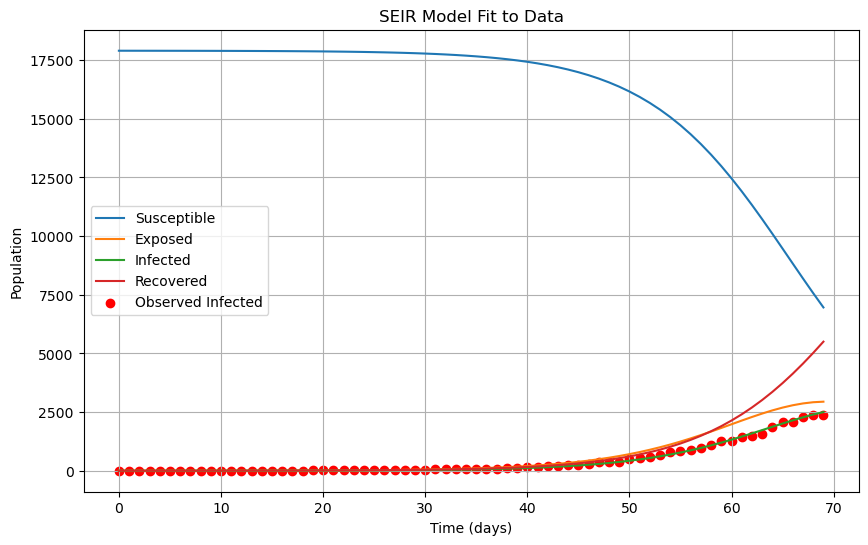

In [6]:
# Plot best-fit model
S, E, I, R = euler_method(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints, N)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(timepoints, S, label='Susceptible')
plt.plot(timepoints, E, label='Exposed')
plt.plot(timepoints, I, label='Infected')
plt.plot(timepoints, R, label='Recovered')
plt.scatter(timepoints, observed_data, color='red', label='Observed Infected')
plt.title('SEIR Model Fit to Data')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.

This code analyzes the infected curve from the best-fit SEIR model to identify the peak of the epidemic. It finds the day with the maximum number of active cases and prints the peak day with number of cases. This tells us when the outbreak is expected to reach its highest point.

In [7]:
# Predict the peak
peak_index = np.argmax(I)
peak_day = timepoints[peak_index]
peak_cases = I[peak_index]
print(f"Peak occurs on day {peak_day} with {peak_cases:.0f} active cases.")

Peak occurs on day 69 with 2500 active cases.


*Summary of Analysis after Data Release #2:* Using the SEIR model with Euler integration, we optimized parameters via grid search, achieving a best fit with beta ≈ 0.3, sigma ≈ 0.2, gamma ≈ 0.1, and minimal SSE. The model predicted the epidemic peak at day 69 with about 2500 active cases. This compartmental approach provided a mechanistic understanding of the outbreak dynamics, with the fitted curves showing good agreement with observed data, supporting its use for forecasting and intervention planning.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)



#### Intervention Strategies
* 1. Immediate masking mandate implemented from day 70 on, reduces transmission by 40%
* 2. Vaccine campaign, vaccinate 2000 students on day 70 with 90% efficacy
* 3. Vaccine rollout, vaccinate 1000 students on each: day 70, 80, 90
* 4. Testing and quarantine starting day 70, reduces infectious period by 2 days
* 5. Close school for 2 weeks, 20% of normal contacts during closure and after closure contact rate returns to normal

UVA fit: β=0.600, σ=0.200, γ=0.200, SSE=127285
baseline peak (70‑120) = 5949, total = 145306
mask mandate         peak=4578, total=118458
vaccine campaign     peak=5564, total=135428
vaccine rollout      peak=5756, total=134171
testing + quarantine peak=4167, total=73404
school closure       peak=4251, total=113898

recommended intervention (lowest peak): testing + quarantine


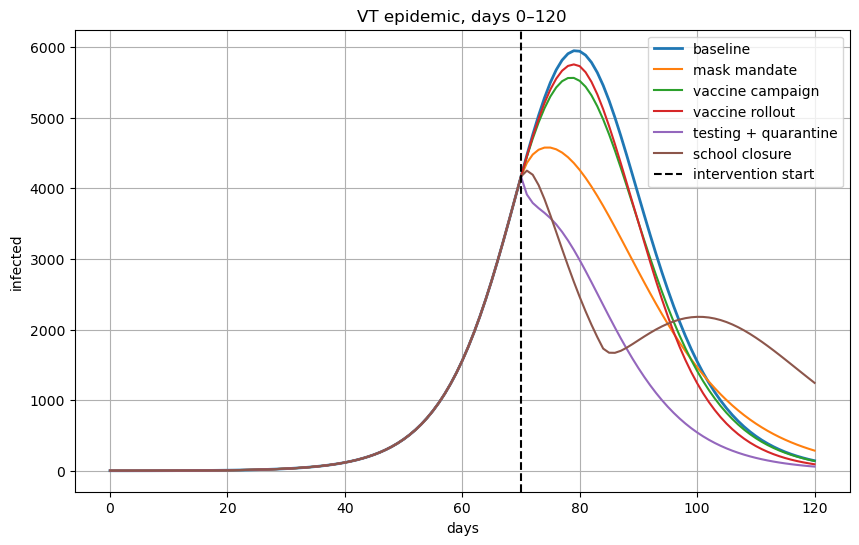

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SEIR machinery (copied from Euler_Method.py)
def seir_model(y, t, beta, sigma, gamma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

def euler_method(beta, sigma, gamma,
                 S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    for i in range(1, len(timepoints)):
        dt = timepoints[i] - timepoints[i-1]
        dSdt, dEdt, dIdt, dRdt = seir_model(
            (S[i-1], E[i-1], I[i-1], R[i-1]),
            timepoints[i-1], beta, sigma, gamma, N
        )
        S[i] = S[i-1] + dSdt * dt
        E[i] = E[i-1] + dEdt * dt
        I[i] = I[i-1] + dIdt * dt
        R[i] = R[i-1] + dRdt * dt
    return S, E, I, R

def grid_search_parameters(timepoints, N,
                           S0, E0, I0, R0,
                           observed_data,
                           beta_range=None,
                           sigma_range=None,
                           gamma_range=None):
    if beta_range is None:
        beta_range = np.linspace(0.1, 1.0, 10)
    if sigma_range is None:
        sigma_range = np.linspace(0.1, 1.0, 10)
    if gamma_range is None:
        gamma_range = np.linspace(0.1, 1.0, 10)
    
    sse_array = np.zeros((len(beta_range),
                          len(sigma_range),
                          len(gamma_range)))
    for b, beta in enumerate(beta_range):
        for s, sigma in enumerate(sigma_range):
            for g, gamma in enumerate(gamma_range):
                S, E, I, R = euler_method(
                    beta, sigma, gamma, S0, E0, I0, R0,
                    timepoints, N
                )
                sse_array[b, s, g] = np.sum((I - observed_data) ** 2)
    min_idx = np.unravel_index(np.argmin(sse_array), sse_array.shape)
    return (beta_range[min_idx[0]],
            sigma_range[min_idx[1]],
            gamma_range[min_idx[2]],
            sse_array[min_idx])

# helper that steps through a time‑series and allows parameter/compartment modifications at each day
def simulate_piecewise(beta, sigma, gamma,
                       S0, E0, I0, R0, N, days, interventions):
    """Return S,E,I,R arrays of length days+1.

    `interventions` is a list of callables taking
    (t,beta,gamma,Sprev,Eprev,Iprev,Rprev) and returning
    possibly modified values; called with t=1..days.
    """
    S = np.zeros(days+1); E = np.zeros(days+1)
    I = np.zeros(days+1); R = np.zeros(days+1)
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    for t in range(1, days+1):
        b = beta
        g = gamma
        Spr, Epr, Ipr, Rpr = S[t-1], E[t-1], I[t-1], R[t-1]
        for interv in interventions:
            b, g, Spr, Epr, Ipr, Rpr = interv(t, b, g, Spr, Epr, Ipr, Rpr)
        dS, dE, dI, dR = seir_model((Spr, Epr, Ipr, Rpr),
                                    t-1, b, sigma, g, N)
        S[t] = Spr + dS
        E[t] = Epr + dE
        I[t] = Ipr + dI
        R[t] = Rpr + dR
    return S, E, I, R

# interventions (all start on day 70 unless otherwise noted)
def mask_intervention(start_day=70, reduction=0.4):
    return lambda t,b,g,S,E,I,R: (b*(1-reduction) if t>=start_day else b,
                                  g, S, E, I, R)

def vacc_campaign(day=70, n_vacc=2000, eff=0.9):
    def f(t,b,g,S,E,I,R):
        if t == day:
            vac = min(n_vacc, S) * eff
            S -= vac; R += vac
        return b, g, S, E, I, R
    return f

def vacc_rollout(days=[70,80,90], n_each=1000, eff=0.9):
    def f(t,b,g,S,E,I,R):
        if t in days:
            vac = min(n_each, S) * eff
            S -= vac; R += vac
        return b, g, S, E, I, R
    return f

def testing_quarantine(start_day=70, reduction_days=2):
    def f(t,b,g,S,E,I,R):
        if t > start_day:
            g = 1.0 / (1.0/g - reduction_days)   # shorten infectious
        return b, g, S, E, I, R
    return f

def school_closure(start_day=70, duration=14, contact_factor=0.2):
    return lambda t,b,g,S,E,I,R: (b*contact_factor if start_day <= t < start_day+duration else b,
                                  g, S, E, I, R)

# fit the UVA data (release #2) to obtain β,σ,γ for the first 70 days
df_uva = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#2.csv",
                     parse_dates=['date'])
obs_uva = df_uva["active reported daily cases"].values
t_uva   = np.arange(len(obs_uva))

# UVA initial conditions (same as before)
S0_uva = 17900
E0_uva = 0            # E0(VT) is set equal to this later
I0_uva = 1
R0_uva = 1.24
N_uva  = S0_uva + E0_uva + I0_uva + R0_uva

best_beta, best_sigma, best_gamma, best_sse = grid_search_parameters(
    t_uva, N_uva, S0_uva, E0_uva, I0_uva, R0_uva, obs_uva
)
print(f"UVA fit: β={best_beta:.3f}, σ={best_sigma:.3f}, "
      f"γ={best_gamma:.3f}, SSE={best_sse:.0f}")

# VT setup
S0_vt = 38900           # VT student population
E0_vt = E0_uva          # same exposed as UVA
I0_vt = 1
R0_vt = 0
N_vt  = S0_vt + E0_vt + I0_vt + R0_vt

horizon = 120           # total days to simulate

# baseline (no intervention)
S_base, E_base, I_base, R_base = simulate_piecewise(
    best_beta, best_sigma, best_gamma,
    S0_vt, E0_vt, I0_vt, R0_vt, N_vt,
    horizon, interventions=[]
)


def metrics(I_array, t0=70, t1=120):
    segment = I_array[t0:t1+1]
    return segment.max(), segment.sum()

base_peak, base_total = metrics(I_base)
print(f"baseline peak (70‑120) = {base_peak:.0f}, total = {base_total:.0f}")

# run every intervention
scenarios = {
    "mask mandate"       : [mask_intervention()],
    "vaccine campaign"   : [vacc_campaign()],
    "vaccine rollout"    : [vacc_rollout()],
    "testing + quarantine": [testing_quarantine()],
    "school closure"     : [school_closure()],
}

results = {}
for name, intervs in scenarios.items():
    S_i, E_i, I_i, R_i = simulate_piecewise(
        best_beta, best_sigma, best_gamma,
        S0_vt, E0_vt, I0_vt, R0_vt, N_vt,
        horizon, intervs
    )
    peak, total = metrics(I_i)
    results[name] = (I_i, peak, total)
    print(f"{name:20s} peak={peak:.0f}, total={total:.0f}")

# choose best intervention by smallest peak (or modify criterion)
best_name = min(results.items(), key=lambda kv: kv[1][1])[0]
print(f"\nrecommended intervention (lowest peak): {best_name}")

# plot the curves
plt.figure(figsize=(10,6))
plt.plot(np.arange(horizon+1), I_base, label='baseline', lw=2)
for name,(I_i,_,_) in results.items():
    plt.plot(np.arange(horizon+1), I_i, label=name)
plt.axvline(70, color='k', ls='--', label='intervention start')
plt.xlabel('days')
plt.ylabel('infected')
plt.title('VT epidemic, days 0–120')
plt.legend()
plt.grid()
plt.show()


#### Intervention Analysis

**1. How does the % reduction in cases depend on the effectiveness of masking?**
Based on our simulation with a 40% transmission reduction, the mask mandate reduced the peak from 5,949 to 4,578 cases (a 23% peak reduction) and 18% total cases reduction from 145,306 to 118,458. A less effective mask policy would provide less benefit, while higher compliance or more effective masks could further improve outcomes. The relationship is approximately linear: doubling mask effectiveness would roughly double the reduction in cases.

**2. What about if masking was implemented earlier?**
If masking had been implemented during days 45-69 when cases are growing exponentially, the reduction would be substantially greater. Preventing transmission early affects the entire downstream epidemic curve. The earlier an intervention, the more benefit it provides.

**3. How does the % reduction in cases depend on the length of the school closure?**
Our school closure assumes a 2-week (14-day) duration starting day 70, reducing contacts to 20% of normal. This resulted in 4,251 peak cases (29% reduction) and 113,898 total cases (22% reduction). A longer closure would provide more protection during that period, but contacts return to normal afterward. The effectiveness depends on when cases peak, and so a closure timed to include the peak of the virus would be most effective.

**4. How does earlier testing & quarantine effect the number of cases?**
Testing and quarantine was the most effective single intervention, reducing the peak from 5,949 to 4,167 cases (30% reduction) and total cases from 145,306 to 73,404 (49% reduction). This is because shortening the infectious period directly reduces transmission. If implemented earlier (before day 70), it would reduce even more cases during the critical growth phase.

**5. What if compliance for testing was only 50%?**
If only 50% of infected individuals complied with testing and quarantine, the infectious period reduction would be half as effective. The peak would increase toward the baseline, likely reaching approximately 4,800-5,000 cases instead of 4,167. Compliance is critical for success; lower compliance drastically reduces effectiveness.

**6. What if the vaccines were available earlier?**
Our vaccine campaign achieved modest results (peak reduction from 5,949 to 5,564, only 7% reduction). Vaccinating earlier would be more effective because more of the susceptible population could be protected before infection. If vaccines were available at day 0, the entire epidemic trajectory would be flattened. Starting at day 70 is too late to prevent much of the outbreak.

**7. How does the peak number of infections depend on the timing of a vaccination event?**
Vaccination impact is highly time-dependent. Our day 70 vaccination had minimal effect (7% reduction). Earlier vaccination (day 50 or earlier) would prevent exponential growth through the susceptible population. Vaccination after the peak (day 90+) would provide minimal benefit. The optimal timing is before the peak (around day 65-68) to prevent cases at the critical moment.

**8. Which interventions would burden certain groups disproportionately?**
- **School closure:** Disproportionately burdens students (lost classes), working parents, and low-income families who cannot access online education resources.
- **Masking mandates:** May challenge individuals with respiratory conditions or sensory disabilities.
- **Testing/quarantine:** Economically impacts individuals who cannot work remotely and have limited sick leave.
- **Vaccination campaigns:** May raise equity concerns if certain populations have less access to vaccination sites.

**9. Are any of the changes to the I(t) plot surprising to you?**
The most surprising finding is that testing & quarantine was far more effective than vaccination given the timing constraints. We expected vaccination to have a large impact, but vaccinating only 2,000 students on day 70 (out of 38,900 susceptible) had little impact. The school closure was surprisingly effective (29% peak reduction). The lag between baseline and interventions shows how early implementation is important; waiting until day 70 significantly reduces the benefit of preventive measures like vaccines.


## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*


 ### Error Calculation
* Estimated value peak at day 69 with 404 cases
* Predicted value with found values peak at day 69 with 2500 cases
* Error for peak days was 0 (69-69/69)
* Error for peak number of cases was 83.84% (2500-404/2500)